In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from sklearn.preprocessing import RobustScaler

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D2 in response_OUS
data = list(OUS_D2['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D2 with response_OUS
clinical_train = pd.merge(OUS_D2, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS', 'LRC', 'event_LRC'])]

In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D2 
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D2['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D2 in response_MAASTRO
data = list(MAASTRO_D2['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D2 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D2, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'DFS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,OS,OS_event
0,1,0.765178,0.610062,30.504395,50.002093,52.886671,58.000000,47.759816,58.864251,38067.208333,...,0.028808,0.837387,0.000026,0.001705,0.122209,0.000026,0.008291,0.000341,62.43,0.0
1,2,0.776540,0.504616,21.069386,41.753334,44.922155,44.294469,44.147480,48.723711,17870.791667,...,0.049615,0.806842,0.000167,0.002958,0.128976,0.000167,0.008148,0.000335,60.00,0.0
2,3,0.697164,0.478604,21.238275,44.375483,48.466483,45.891176,37.656341,48.969378,17426.500000,...,0.019514,0.830272,0.000057,0.001831,0.137282,0.000000,0.008641,0.000229,44.43,1.0
3,4,0.574636,0.446059,20.570459,46.115989,42.544095,47.507894,33.837849,55.226805,12463.791667,...,0.047155,0.760949,0.000000,0.003597,0.171595,0.000080,0.013187,0.000240,37.20,1.0
4,6,0.633419,0.480378,26.130155,54.394967,66.030296,56.320511,45.398238,67.089492,28300.125000,...,0.033990,0.824865,0.000000,0.002116,0.128134,0.000035,0.009379,0.000529,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,0.882411,0.577884,19.774388,34.218615,41.785165,40.261644,35.805028,43.520110,12822.458333,...,0.017489,0.834590,0.000000,0.001321,0.137194,0.000078,0.008706,0.000078,19.00,1.0
95,111,0.535802,0.455642,23.259099,51.046869,51.264022,51.264022,33.600595,52.440442,18368.291667,...,0.029979,0.821431,0.000000,0.000543,0.137620,0.000054,0.008907,0.000489,85.87,1.0
96,112,0.716610,0.631485,31.838169,50.417953,46.324939,56.035703,57.070132,57.671483,35384.541667,...,0.017354,0.859957,0.000000,0.000988,0.115099,0.000028,0.005700,0.000141,42.87,0.0
97,113,0.665145,0.628338,28.213278,44.901412,50.289164,50.596443,35.777088,51.478151,26180.208333,...,0.025399,0.847908,0.000000,0.001487,0.117654,0.000000,0.005759,0.000038,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,OS,OS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS'])]

# y 
y = clinical_train.loc[:, ['OS', 'event_OS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 374)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'OS_event' : 'event_OS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'event_OS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['OS', 'event_OS']]
lower, upper = np.percentile(y_MAASTRO['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_OS'], y_MAASTRO['OS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 376)

# Standardization for Clustering

In [17]:
original_X = X.copy()

In [18]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

### Standardize non-categorical and then concat with the categorical
scaler = RobustScaler()  
X_std = scaler.fit_transform(X)
X_std = pd.DataFrame(X_std, columns=X.columns, index=X.index)

In [19]:
X_std

,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,...,LBP_003_PET,LBP_012_PET,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET
0,-0.485459,0.064971,0.106464,0.059912,0.040088,0.016991,-0.128772,0.030929,0.088920,-0.225260,...,1.259511,-0.187895,-0.237601,0.332001,0.000000,-0.255811,-0.228027,0.038290,-0.362826,-0.200426
1,0.666232,-0.952446,-1.099567,-0.755402,-0.875769,-0.824341,-0.652457,-0.744926,-0.477418,-0.603339,...,3.566490,3.137073,0.913224,-1.314176,0.000000,2.591499,1.070407,1.827361,1.866886,0.869468
2,0.337179,0.444285,0.660909,0.338093,0.468616,0.259750,0.440538,0.543698,0.630069,0.754279,...,0.000000,0.082981,0.129427,0.390580,0.524263,-0.050487,-0.580607,-0.345359,-0.452526,-0.057457
3,0.695653,-0.718597,-0.979079,-0.709822,-0.930040,-0.881308,-0.331090,-0.564759,-0.457375,-0.522339,...,3.059892,2.449854,0.967575,-1.179161,0.000000,0.280373,1.104438,-0.345359,1.114908,1.522258
4,0.617917,-0.496529,-0.535096,-0.285114,-0.602328,-0.244920,-0.174518,-0.266658,-0.386906,0.069107,...,0.000000,0.190665,0.869189,-1.477904,3.028668,2.691677,1.352218,2.133915,2.946000,3.137491
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,-0.105628,-0.004852,-0.358757,-0.360532,-0.402004,-0.263575,-0.567218,-0.358084,-0.246111,-0.455811,...,0.000000,-0.007844,-0.258121,0.163381,0.000000,-0.508000,0.087068,-0.345359,-0.405549,-0.231420
135,0.267171,1.278289,0.793049,0.011834,0.186224,0.312548,0.304548,0.236335,0.478786,0.257736,...,0.401955,0.179343,0.399712,-0.028726,0.000000,0.619505,-0.164891,0.144386,-0.060514,0.645662
136,0.324219,0.748713,0.215283,-0.194798,-0.504568,-0.064017,0.452283,-0.154471,0.051287,0.016210,...,0.000000,-0.577753,-0.765863,0.578039,0.000000,-0.732668,-0.221085,-0.345359,-0.504845,0.294840
137,-0.351598,-0.195069,0.112013,0.237230,0.100387,0.086725,0.028168,0.200249,0.183658,0.069765,...,0.000000,-0.253379,0.106163,-0.097845,0.000000,0.215431,0.189762,-0.008205,-0.032466,0.889136


# Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

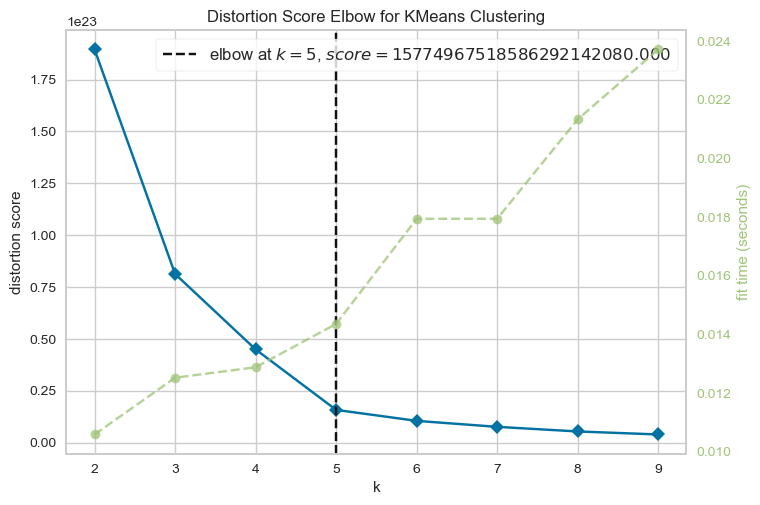

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [20]:
# Choose how many clusters to make 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

In [21]:
num_clusters = 5  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(5):
    variance = X_std[X_std.columns[cluster_labels==i]].var()

    # Find the most correlated column
    high_variance_column = variance.abs().idxmax()

    # Get the correlation coefficient of the most correlated column
    max_variance = variance.abs().max()

    print(i)
    print("Most correlated column:", high_variance_column)
    print("Correlation coefficient:", max_variance)
    print('\n')
    selected_features.append(high_variance_column)

KMeans(n_clusters=5)

0
Most correlated column: glcm_ClusterProminence_d_1_CT_c16
Correlation coefficient: 14.377279628375122


1
Most correlated column: glszm_LargeAreaLowGrayLevelEmphasis_PET_c04
Correlation coefficient: 5087.237820106097


2
Most correlated column: glszm_LargeAreaLowGrayLevelEmphasis_PET_b2
Correlation coefficient: 1055.19167151558


3
Most correlated column: glszm_LargeAreaLowGrayLevelEmphasis_CT_c16
Correlation coefficient: 70.1247383577268


4
Most correlated column: gldm_LargeDependenceLowGrayLevelEmphasis_d_1_CT_b20
Correlation coefficient: 46.818339041452326




In [22]:
selected_features

['glcm_ClusterProminence_d_1_CT_c16',
 'glszm_LargeAreaLowGrayLevelEmphasis_PET_c04',
 'glszm_LargeAreaLowGrayLevelEmphasis_PET_b2',
 'glszm_LargeAreaLowGrayLevelEmphasis_CT_c16',
 'gldm_LargeDependenceLowGrayLevelEmphasis_d_1_CT_b20']

In [23]:
# Selecting features in the DataFrame
X_fs_hv = X[selected_features]
X_new = X_fs_hv.copy()

X_MAASTRO_fs_hv = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_hv.copy()

# Standardization

In [24]:
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = RobustScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [25]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_std[MAASTRO_new.columns]

In [26]:
X_new

,glcm_ClusterProminence_d_1_CT_c16,glszm_LargeAreaLowGrayLevelEmphasis_PET_c04,glszm_LargeAreaLowGrayLevelEmphasis_PET_b2,glszm_LargeAreaLowGrayLevelEmphasis_CT_c16,gldm_LargeDependenceLowGrayLevelEmphasis_d_1_CT_b20
0,64.095710,879096.343994,2.625216e+05,7442.066260,0.056560
1,179.749734,26566.901706,1.242203e+05,238.870676,0.095346
2,141.966662,647295.586841,2.397332e+06,12957.157420,0.052264
3,214.472104,40145.962374,1.252457e+06,233.632355,0.027762
4,610.141126,10927.978256,1.366458e+05,121.921768,0.034148
...,...,...,...,...,...
134,39.310068,215024.891557,4.128076e+05,1528.464999,0.176183
135,96.763592,338158.975184,3.892908e+06,41182.958565,0.148848
136,201.685960,974304.249507,1.734434e+05,3964.057173,0.130961
137,95.689874,199030.525466,1.164868e+06,5243.112516,0.258550


In [27]:
X_new_std

,glcm_ClusterProminence_d_1_CT_c16,glszm_LargeAreaLowGrayLevelEmphasis_PET_c04,glszm_LargeAreaLowGrayLevelEmphasis_PET_b2,glszm_LargeAreaLowGrayLevelEmphasis_CT_c16,gldm_LargeDependenceLowGrayLevelEmphasis_d_1_CT_b20
0,-0.274288,0.627985,-0.165378,0.233483,-0.473236
1,-0.041074,-0.249270,-0.309221,-0.164858,-0.033964
2,-0.117263,0.389462,2.054971,0.538471,-0.521881
3,0.028943,-0.235297,0.864223,-0.165148,-0.799374
4,0.826802,-0.265362,-0.296297,-0.171326,-0.727051
...,...,...,...,...,...
134,-0.324268,-0.055346,-0.009070,-0.093543,0.881543
135,-0.208414,0.071360,3.610473,2.099375,0.571968
136,0.003160,0.725955,-0.258025,0.041147,0.369390
137,-0.210579,-0.071804,0.773124,0.111879,1.814381


In [28]:
MAASTRO_new

,glcm_ClusterProminence_d_1_CT_c16,glszm_LargeAreaLowGrayLevelEmphasis_PET_c04,glszm_LargeAreaLowGrayLevelEmphasis_PET_b2,glszm_LargeAreaLowGrayLevelEmphasis_CT_c16,gldm_LargeDependenceLowGrayLevelEmphasis_d_1_CT_b20
0,156.527507,1.125054e+06,3.686456e+05,9404.025346,0.203608
1,447.924077,1.948450e+06,2.114589e+06,16468.863361,0.077923
2,784.580957,1.403912e+06,4.579214e+05,3829.811759,0.119332
3,1564.507789,4.555744e+05,9.121242e+05,2212.056593,1.487269
4,26.806072,8.660429e+05,3.260921e+06,20185.616389,0.129126
...,...,...,...,...,...
94,80.816281,9.500595e+05,5.034748e+04,18006.593217,0.097901
95,5250.361286,3.718008e+06,8.736992e+05,1303.136099,0.135426
96,238.811635,2.726200e+06,7.999319e+06,8928.353080,0.083343
97,56.598117,2.138315e+06,6.943470e+05,13835.684015,0.071296


In [29]:
MAASTRO_new_std

,glcm_ClusterProminence_d_1_CT_c16,glszm_LargeAreaLowGrayLevelEmphasis_PET_c04,glszm_LargeAreaLowGrayLevelEmphasis_PET_b2,glszm_LargeAreaLowGrayLevelEmphasis_CT_c16,gldm_LargeDependenceLowGrayLevelEmphasis_d_1_CT_b20
0,-0.087901,0.881077,-0.055002,0.341981,1.192147
1,0.499694,1.728353,1.760899,0.732670,-0.231290
2,1.178557,1.168022,0.037851,0.033723,0.237686
3,2.751265,0.192180,0.510253,-0.055740,15.730108
4,-0.349482,0.614553,2.953163,0.938209,0.348610
...,...,...,...,...,...
94,-0.240572,0.701007,-0.386054,0.817708,-0.005024
95,10.183719,3.549233,0.470289,-0.106004,0.419960
96,0.078023,2.528660,7.881422,0.315676,-0.169908
97,-0.289407,1.923725,0.283750,0.587054,-0.306341


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [30]:
# Setting the y format for skf below  
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-16 00:42:15,238] A new study created in memory with name: no-name-e2a46b34-0582-4a50-b2e1-88e6537a368b
python(80999) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-16 00:42:15,478] A new study created in memory with name: no-name-5d94758a-58df-41a8-920f-68795d08a42c


Fold 1 C-index: 0.6320346320346321
Fold 2 C-index: 0.7232142857142857
Fold 3 C-index: 0.4803921568627451
Fold 4 C-index: 0.6371308016877637
Fold 5 C-index: 0.5727699530516432
[I 2024-04-16 00:42:15,475] Trial 0 finished with value: 0.6091083658702139 and parameters: {}. Best is trial 0 with value: 0.6091083658702139.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6091083658702139], datetime_start=datetime.datetime(2024, 4, 16, 0, 42, 15, 309700), datetime_complete=datetime.datetime(2024, 4, 16, 0, 42, 15, 475237), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6091083658702139


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.18000796011578504
Fold 2 IBS: 0.19065894624157773
Fold 3 IBS: 0.1870667462761146
Fold 4 IBS: 0.20335763233698795
Fold 5 IBS: 0.22033366958218034
[I 2024-04-16 00:42:15,701] Trial 0 finished with value: 0.19628499091052914 and parameters: {}. Best is trial 0 with value: 0.19628499091052914.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.19628499091052914], datetime_start=datetime.datetime(2024, 4, 16, 0, 42, 15, 495764), datetime_complete=datetime.datetime(2024, 4, 16, 0, 42, 15, 701684), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.19628499091052914


In [31]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [32]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.609
train_ibs:  0.196


#### Test

In [33]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [34]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.533
IBS score: 0.23


In [35]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [36]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [37]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 00:42:15,829] A new study created in memory with name: no-name-5410d557-181c-47a0-9249-b460a6edff7f


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6277056277056277
Fold 2 C-index: 0.7566964285714286
Fold 3 C-index: 0.6421568627450981


[I 2024-04-16 00:42:15,952] A new study created in memory with name: no-name-9d9ab724-962d-47fb-a2fa-0cf6b0bf37e0


Fold 4 C-index: 0.689873417721519
Fold 5 C-index: 0.5610328638497653
[I 2024-04-16 00:42:15,944] Trial 0 finished with value: 0.6554930401186878 and parameters: {}. Best is trial 0 with value: 0.6554930401186878.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6554930401186878], datetime_start=datetime.datetime(2024, 4, 16, 0, 42, 15, 868871), datetime_complete=datetime.datetime(2024, 4, 16, 0, 42, 15, 944284), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6554930401186878


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2139765137081334
Fold 2 IBS: 0.22157791506947716
Fold 3 IBS: 0.2045359371128086
Fold 4 IBS: 0.22473801555959494
Fold 5 IBS: 0.2181243168929564
[I 2024-04-16 00:42:16,097] Trial 0 finished with value: 0.2165905396685941 and parameters: {}. Best is trial 0 with value: 0.2165905396685941.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2165905396685941], datetime_start=datetime.datetime(2024, 4, 16, 0, 42, 15, 996840), datetime_complete=datetime.datetime(2024, 4, 16, 0, 42, 16, 97273), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2165905396685941


In [38]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [39]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.655
train_ibs:  0.217


#### Test

In [40]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [41]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.599


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.221


In [42]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [43]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 00:42:16,215] A new study created in memory with name: no-name-d212b528-8dc3-435a-8c6b-e5f06fd00402


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.7276785714285714
Fold 3 C-index: 0.47058823529411764
Fold 4 C-index: 0.6371308016877637
Fold 5 C-index: 0.568075117370892
[I 2024-04-16 00:42:16,489] Trial 0 finished with value: 0.6105646750263988 and parameters: {}. Best is trial 0 with value: 0.6105646750263988.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6105646750263988], datetime_start=datetime.datetime(2024, 4, 16, 0, 42, 16, 237229), datetime_complete=datetime.datetime(2024, 4, 16, 0, 42, 16, 488839), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6105646750263988


[I 2024-04-16 00:42:16,495] A new study created in memory with name: no-name-450fd811-7d2b-49a7-b95e-65b0983d53a2


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.18081164198350358
Fold 2 IBS: 0.1912317991631802
Fold 3 IBS: 0.18625296649364637
Fold 4 IBS: 0.20315267161646275
Fold 5 IBS: 0.2201612268119091
[I 2024-04-16 00:42:16,755] Trial 0 finished with value: 0.19632206121374038 and parameters: {}. Best is trial 0 with value: 0.19632206121374038.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.19632206121374038], datetime_start=datetime.datetime(2024, 4, 16, 0, 42, 16, 521620), datetime_complete=datetime.datetime(2024, 4, 16, 0, 42, 16, 755296), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.19632206121374038


In [44]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [45]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.611
train_ibs:  0.196


#### Test

In [46]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [47]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.535


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.229


In [48]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [49]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 00:42:16,931] A new study created in memory with name: no-name-029d380f-c693-4c24-9fe9-47c6d008f8f6


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.7276785714285714
Fold 3 C-index: 0.47058823529411764
Fold 4 C-index: 0.6371308016877637
Fold 5 C-index: 0.568075117370892
[I 2024-04-16 00:42:17,190] Trial 0 finished with value: 0.6105646750263988 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.6105646750263988.
Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.7276785714285714
Fold 3 C-index: 0.47058823529411764
Fold 4 C-index: 0.6371308016877637
Fold 5 C-index: 0.568075117370892
[I 2024-04-16 00:42:17,383] Trial 1 finished with value: 0.6105646750263988 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.6105646750263988.
Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.7276785714285714
Fold 3 C-index: 0.47058823529411764
Fold 4 C-index: 0.6371308016877637
Fold 5 C-index: 0.568075117370892
[I 2024-04-16 00:42:17,615] Trial 2 finished with value: 0.6105646750263988 and parameters: {'l1_ratio': 0.22692876841884668}.

Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.7276785714285714
Fold 3 C-index: 0.47058823529411764
Fold 4 C-index: 0.6371308016877637
Fold 5 C-index: 0.568075117370892
[I 2024-04-16 00:42:21,536] Trial 24 finished with value: 0.6105646750263988 and parameters: {'l1_ratio': 0.15433706302991543}. Best is trial 0 with value: 0.6105646750263988.
Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.7276785714285714
Fold 3 C-index: 0.47058823529411764
Fold 4 C-index: 0.6371308016877637
Fold 5 C-index: 0.568075117370892
[I 2024-04-16 00:42:21,698] Trial 25 finished with value: 0.6105646750263988 and parameters: {'l1_ratio': 0.4626599986704694}. Best is trial 0 with value: 0.6105646750263988.
Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.7276785714285714
Fold 3 C-index: 0.47058823529411764
Fold 4 C-index: 0.6371308016877637
Fold 5 C-index: 0.568075117370892
[I 2024-04-16 00:42:21,852] Trial 26 finished with value: 0.6105646750263988 and parameters: {'l1_ratio': 0.3312072877416866

Fold 2 C-index: 0.7276785714285714
Fold 3 C-index: 0.47058823529411764
Fold 4 C-index: 0.6371308016877637
Fold 5 C-index: 0.568075117370892
[I 2024-04-16 00:42:25,332] Trial 48 finished with value: 0.6105646750263988 and parameters: {'l1_ratio': 0.5675456270820948}. Best is trial 0 with value: 0.6105646750263988.
Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.7276785714285714
Fold 3 C-index: 0.47058823529411764
Fold 4 C-index: 0.6371308016877637
Fold 5 C-index: 0.568075117370892
[I 2024-04-16 00:42:25,490] Trial 49 finished with value: 0.6105646750263988 and parameters: {'l1_ratio': 0.7153190338760974}. Best is trial 0 with value: 0.6105646750263988.
Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.7276785714285714
Fold 3 C-index: 0.47058823529411764
Fold 4 C-index: 0.6371308016877637
Fold 5 C-index: 0.568075117370892
[I 2024-04-16 00:42:25,651] Trial 50 finished with value: 0.6105646750263988 and parameters: {'l1_ratio': 0.5027665121167861}. Best is trial 0 with value: 0.610

...

  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.18076298900288884
Fold 2 IBS: 0.19123404548719436
Fold 3 IBS: 0.1862493147337608
Fold 4 IBS: 0.2031419928454181
Fold 5 IBS: 0.2201596282246275
[I 2024-04-16 00:42:33,534] Trial 0 finished with value: 0.19630959405877793 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.19630959405877793.
Fold 1 IBS: 0.18078096042179662
Fold 2 IBS: 0.19122589136186102
Fold 3 IBS: 0.18627089236346756
Fold 4 IBS: 0.20311305116656125
Fold 5 IBS: 0.22016138317212589
[I 2024-04-16 00:42:33,703] Trial 1 finished with value: 0.19631043569716247 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.19630959405877793.
Fold 1 IBS: 0.1807891234787577
Fold 2 IBS: 0.19122671161985483
Fold 3 IBS: 0.18626307332304043
Fold 4 IBS: 0.20309317301147
Fold 5 IBS: 0.22016843573258474
[I 2024-04-16 00:42:33,888] Trial 2 finished with value: 0.19630810343314153 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 2 with value: 0.1963081034331415

Fold 4 IBS: 0.20297178142015063
Fold 5 IBS: 0.2201607716062045
[I 2024-04-16 00:42:37,732] Trial 25 finished with value: 0.19629943151604673 and parameters: {'l1_ratio': 0.03981317955666948}. Best is trial 12 with value: 0.19629737871807512.
Fold 1 IBS: 0.18079731009296465
Fold 2 IBS: 0.1912297968744767
Fold 3 IBS: 0.18625484982513343
Fold 4 IBS: 0.20309545146268643
Fold 5 IBS: 0.22016487539208565
[I 2024-04-16 00:42:37,890] Trial 26 finished with value: 0.19630845672946934 and parameters: {'l1_ratio': 0.18783928730207888}. Best is trial 12 with value: 0.19629737871807512.
Fold 1 IBS: 0.18076611058738573
Fold 2 IBS: 0.19123347396953286
Fold 3 IBS: 0.1862457988868
Fold 4 IBS: 0.20313526688110206
Fold 5 IBS: 0.22015809186241952
[I 2024-04-16 00:42:38,054] Trial 27 finished with value: 0.19630774843744805 and parameters: {'l1_ratio': 0.58416616744615}. Best is trial 12 with value: 0.19629737871807512.
Fold 1 IBS: 0.18079081060719793
Fold 2 IBS: 0.1912163135429132
Fold 3 IBS: 0.18628772032

Fold 1 IBS: 0.18076585051890953
Fold 2 IBS: 0.19123509599800415
Fold 3 IBS: 0.18624668486688506
Fold 4 IBS: 0.2031359426118932
Fold 5 IBS: 0.22015831899703808
[I 2024-04-16 00:42:41,728] Trial 50 finished with value: 0.196308378598546 and parameters: {'l1_ratio': 0.5938078108685914}. Best is trial 31 with value: 0.19629363770433583.
Fold 1 IBS: 0.18088659443650834
Fold 2 IBS: 0.19120203968913838
Fold 3 IBS: 0.1863031705311031
Fold 4 IBS: 0.2029284731571604
Fold 5 IBS: 0.2201616780499252
[I 2024-04-16 00:42:41,901] Trial 51 finished with value: 0.1962963911727671 and parameters: {'l1_ratio': 0.024650363292319316}. Best is trial 31 with value: 0.19629363770433583.
Fold 1 IBS: 0.18082356091081672
Fold 2 IBS: 0.19121090659899526
Fold 3 IBS: 0.18631409443861405
Fold 4 IBS: 0.20297898378026763
Fold 5 IBS: 0.22016943537965597
[I 2024-04-16 00:42:42,091] Trial 52 finished with value: 0.19629939622166992 and parameters: {'l1_ratio': 0.03259983637172203}. Best is trial 31 with value: 0.196293637

Fold 3 IBS: 0.1863227574292974
Fold 4 IBS: 0.20296475300652955
Fold 5 IBS: 0.220169472176715
[I 2024-04-16 00:42:46,138] Trial 75 finished with value: 0.19630441110404043 and parameters: {'l1_ratio': 0.02776858431846198}. Best is trial 31 with value: 0.19629363770433583.
Fold 1 IBS: 0.1807913023352559
Fold 2 IBS: 0.19121522087066953
Fold 3 IBS: 0.1862870709555874
Fold 4 IBS: 0.2030411790550837
Fold 5 IBS: 0.2201665024238909
[I 2024-04-16 00:42:46,313] Trial 76 finished with value: 0.19630025512809748 and parameters: {'l1_ratio': 0.0907882185149599}. Best is trial 31 with value: 0.19629363770433583.
Fold 1 IBS: 0.18079093975065572
Fold 2 IBS: 0.19122767451899256
Fold 3 IBS: 0.186260697927118
Fold 4 IBS: 0.2030879943529527
Fold 5 IBS: 0.22016729374751873
[I 2024-04-16 00:42:46,491] Trial 77 finished with value: 0.19630692005944755 and parameters: {'l1_ratio': 0.21521511330008186}. Best is trial 31 with value: 0.19629363770433583.
Fold 1 IBS: 0.18083027514336694
Fold 2 IBS: 0.191212830452

In [50]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [51]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.611
train_ibs:  0.196


#### Test

In [52]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [53]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.6964995386793018)

test_cindex : 0.535


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.02170034925862502)

test_ibs:  0.229


In [54]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [55]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-16 00:42:50,235] A new study created in memory with name: no-name-5c55a084-56b1-4bc7-baba-168fe38541fc


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6341991341991342
Fold 2 C-index: 0.7723214285714286
Fold 3 C-index: 0.6372549019607843
Fold 4 C-index: 0.6497890295358649
Fold 5 C-index: 0.6291079812206573
[I 2024-04-16 00:42:51,519] Trial 0 finished with value: 0.6645344950975739 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.6645344950975739.
Fold 1 C-index: 0.6103896103896104
Fold 2 C-index: 0.6875
Fold 3 C-index: 0.6078431372549019
Fold 4 C-index: 0.6497890295358649
Fold 5 C-index: 0.6056338028169014
[I 2024-04-16 00:42:52,419] Trial 1 finished with value: 0.6322311159994558 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 'max_feature

Fold 3 C-index: 0.6568627450980392
Fold 4 C-index: 0.6540084388185654
Fold 5 C-index: 0.6431924882629108
[I 2024-04-16 00:43:09,867] Trial 15 finished with value: 0.6840757214488902 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 15, 'min_samples_leaf': 2, 'max_depth': 17, 'n_estimators': 491, 'oob_score': True, 'max_samples': 0.25141113328809755, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.08807762154599924, 'warm_start': True}. Best is trial 14 with value: 0.6966753929565798.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 00:43:10,471] Trial 16 finished with value: 0.5 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 15, 'min_samples_leaf': 1, 'max_depth': 16, 'n_estimators': 122, 'oob_score': True, 'max_samples': 0.14975474925617, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.08683497083568477, 'warm_start': True}. Best is trial 14 with value: 0.6966753929565798.
Fold 1 C-inde

Fold 1 C-index: 0.6233766233766234
Fold 2 C-index: 0.8258928571428571
Fold 3 C-index: 0.696078431372549
Fold 4 C-index: 0.759493670886076
Fold 5 C-index: 0.7464788732394366
[I 2024-04-16 00:43:28,871] Trial 31 finished with value: 0.7302640912035084 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 20, 'min_samples_leaf': 6, 'max_depth': 7, 'n_estimators': 460, 'oob_score': True, 'max_samples': 0.5119028984984925, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.041335194314376336, 'warm_start': True}. Best is trial 25 with value: 0.790608210455449.
Fold 1 C-index: 0.6406926406926406
Fold 2 C-index: 0.8214285714285714
Fold 3 C-index: 0.6666666666666666
Fold 4 C-index: 0.70042194092827
Fold 5 C-index: 0.6619718309859155
[I 2024-04-16 00:43:29,813] Trial 32 finished with value: 0.6982363301404128 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 19, 'min_samples_leaf': 3, 'max_depth': 6, 'n_estimators': 432, 'oob_score': True, 'max_samples': 0.5655810826331389, 'ma

...

Fold 1 IBS: 0.2011405840336473
Fold 2 IBS: 0.17401000354303792
Fold 3 IBS: 0.191499055679347
Fold 4 IBS: 0.20583896144346642
Fold 5 IBS: 0.22477911985124338
[I 2024-04-16 00:45:00,633] Trial 32 finished with value: 0.19945354491014838 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 10, 'min_samples_leaf': 16, 'max_depth': 6, 'n_estimators': 310, 'oob_score': False, 'max_samples': 0.6952827586042977, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.17283958091192597}. Best is trial 12 with value: 0.19803451825222645.
Fold 1 IBS: 0.197687924981718
Fold 2 IBS: 0.1778235086787247
Fold 3 IBS: 0.1919174442210459
Fold 4 IBS: 0.2079190936866609
Fold 5 IBS: 0.21848934243846577
[I 2024-04-16 00:45:01,782] Trial 33 finished with value: 0.19876746280132304 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 8, 'min_samples_leaf': 19, 'max_depth': 3, 'n_estimators': 240, 'oob_score': False, 'max_samples': 0.6225304823092432, 'max_features': 'sqrt', 'min_weight_fraction_leaf

Fold 5 IBS: 0.2373453119827217
[I 2024-04-16 00:45:22,504] Trial 47 finished with value: 0.2047827285408327 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 6, 'min_samples_leaf': 4, 'max_depth': 2, 'n_estimators': 198, 'oob_score': True, 'max_samples': 0.7874658506354026, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.0869393694585497}. Best is trial 44 with value: 0.1977662252240056.
Fold 1 IBS: 0.21395754156196922
Fold 2 IBS: 0.22037925861845895
Fold 3 IBS: 0.20507639163389002
Fold 4 IBS: 0.2249269339063041
Fold 5 IBS: 0.21726211813610183
[I 2024-04-16 00:45:23,715] Trial 48 finished with value: 0.21632044877134482 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 10, 'min_samples_leaf': 19, 'max_depth': 5, 'n_estimators': 255, 'oob_score': False, 'max_samples': 0.1428225879209601, 'max_features': None, 'min_weight_fraction_leaf': 0.44962767788541247}. Best is trial 44 with value: 0.1977662252240056.
Fold 1 IBS: 0.19846987978514935
Fold 2 IBS: 0.173653799

Fold 1 IBS: 0.1999113959331955
Fold 2 IBS: 0.1726446324102124
Fold 3 IBS: 0.1917319938756196
Fold 4 IBS: 0.2042107829117051
Fold 5 IBS: 0.22238878369458887
[I 2024-04-16 00:45:32,267] Trial 63 finished with value: 0.1981775177650643 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 2, 'min_samples_leaf': 13, 'max_depth': 4, 'n_estimators': 103, 'oob_score': True, 'max_samples': 0.7313617215617654, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.21085794624372625}. Best is trial 60 with value: 0.19742454221740197.
Fold 1 IBS: 0.21404968305426794
Fold 2 IBS: 0.2226590157519496
Fold 3 IBS: 0.20406549773172375
Fold 4 IBS: 0.2258577030779227
Fold 5 IBS: 0.21913900750460505
[I 2024-04-16 00:45:33,062] Trial 64 finished with value: 0.21715418142409382 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 3, 'min_samples_leaf': 8, 'max_depth': 5, 'n_estimators': 26, 'oob_score': True, 'max_samples': 0.5939962187729074, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.3

Fold 2 IBS: 0.1744891513120787
Fold 3 IBS: 0.1925894553679759
Fold 4 IBS: 0.20690497459007257
Fold 5 IBS: 0.2185599648525911
[I 2024-04-16 00:45:41,877] Trial 79 finished with value: 0.19825969435980745 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 5, 'min_samples_leaf': 8, 'max_depth': 3, 'n_estimators': 116, 'oob_score': True, 'max_samples': 0.7084817086151829, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.2731171264189524}. Best is trial 71 with value: 0.19647088491652642.
Fold 1 IBS: 0.20316517399683529
Fold 2 IBS: 0.17445606756966417
Fold 3 IBS: 0.19113332913153833
Fold 4 IBS: 0.2061123175480538
Fold 5 IBS: 0.22881918607651838
[I 2024-04-16 00:45:42,162] Trial 80 finished with value: 0.20073721486452198 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 3, 'min_samples_leaf': 11, 'max_depth': 5, 'n_estimators': 32, 'oob_score': True, 'max_samples': 0.7411316958421282, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.1666633911920333}. Best is tria

Fold 1 IBS: 0.20103123157118447
Fold 2 IBS: 0.17651014863574904
Fold 3 IBS: 0.19169003055630335
Fold 4 IBS: 0.2135682370615408
Fold 5 IBS: 0.2166315560917566
[I 2024-04-16 00:45:58,404] Trial 95 finished with value: 0.19988624078330686 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 4, 'min_samples_leaf': 11, 'max_depth': 1, 'n_estimators': 39, 'oob_score': True, 'max_samples': 0.6044762275035641, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.2610713823166372}. Best is trial 71 with value: 0.19647088491652642.
Fold 1 IBS: 0.19785678094659417
Fold 2 IBS: 0.16914427340117172
Fold 3 IBS: 0.19065444907163534
Fold 4 IBS: 0.20731540327974948
Fold 5 IBS: 0.21954889538881706
[I 2024-04-16 00:45:59,159] Trial 96 finished with value: 0.19690396041759356 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 5, 'min_samples_leaf': 15, 'max_depth': 2, 'n_estimators': 65, 'oob_score': True, 'max_samples': 0.5730155413668798, 'max_features': 'auto', 'min_weight_fraction_leaf':

In [56]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [57]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.817
train_ibs:  0.196


#### Test

In [58]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [59]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=5, max_leaf_nodes=17,
                     max_samples=0.899918085166763, min_samples_leaf=2,
                     min_samples_split=5,
                     min_weight_fraction_leaf=0.021575593572846434,
                     n_estimators=184, oob_score=True, random_state=123,
                     warm_start=True)

test_cindex:  0.617


RandomSurvivalForest(max_depth=2, max_features='auto', max_leaf_nodes=4,
                     max_samples=0.7321148228618468, min_samples_leaf=10,
                     min_samples_split=4,
                     min_weight_fraction_leaf=0.17337489514228752,
                     n_estimators=10, oob_score=True, random_state=123)

test_ibs:  0.211


In [60]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [61]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 00:46:02,074] A new study created in memory with name: no-name-d53ba531-0b65-4f48-bc5b-eb805a0627c4


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6060606060606061
Fold 2 C-index: 0.7901785714285714
Fold 3 C-index: 0.6519607843137255
Fold 4 C-index: 0.6582278481012658
Fold 5 C-index: 0.6572769953051644
[I 2024-04-16 00:46:02,789] Trial 0 finished with value: 0.6727409610418666 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.6727409610418666.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 00:46:04,674] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 00:46:32,636] Trial 16 finished with value: 0.5 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 17, 'min_samples_leaf': 7, 'max_depth': 3, 'n_estimators': 497, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.10043506002193597, 'min_weight_fraction_leaf': 0.4093818399278544}. Best is trial 11 with value: 0.6754576015968553.
Fold 1 C-index: 0.6082251082251082
Fold 2 C-index: 0.8035714285714286
Fold 3 C-index: 0.6642156862745098
Fold 4 C-index: 0.6139240506329114
Fold 5 C-index: 0.6666666666666666
[I 2024-04-16 00:46:34,662] Trial 17 finished with value: 0.6713205880741249 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 10, 'min_samples_leaf': 4, 'max_depth': 16, 'n_estimators': 381, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.680642613858846, 'min_weight_fraction_leaf': 0.1923905010311

Fold 1 C-index: 0.6233766233766234
Fold 2 C-index: 0.8169642857142857
Fold 3 C-index: 0.6225490196078431
Fold 4 C-index: 0.6497890295358649
Fold 5 C-index: 0.6103286384976526
[I 2024-04-16 00:47:03,975] Trial 31 finished with value: 0.664601519346454 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 3, 'min_samples_leaf': 4, 'max_depth': 12, 'n_estimators': 234, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.5109549718330393, 'min_weight_fraction_leaf': 0.0810364484786845}. Best is trial 11 with value: 0.6754576015968553.
Fold 1 C-index: 0.6017316017316018
Fold 2 C-index: 0.8348214285714286
Fold 3 C-index: 0.6323529411764706
Fold 4 C-index: 0.6244725738396625
Fold 5 C-index: 0.6338028169014085
[I 2024-04-16 00:47:04,712] Trial 32 finished with value: 0.6654362724441143 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 3, 'min_samples_leaf': 6, 'max_depth': 13, 'n_estimators': 142, 'oob_score': False, 'warm_start': True, 'max_features'

...

Fold 1 IBS: 0.2139847505995551
Fold 2 IBS: 0.22074692995770445
Fold 3 IBS: 0.2053814169468165
Fold 4 IBS: 0.22479380650462077
Fold 5 IBS: 0.21735940240214482
[I 2024-04-16 00:50:56,186] Trial 30 finished with value: 0.21645326128216835 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 8, 'min_samples_leaf': 9, 'max_depth': 15, 'n_estimators': 355, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.1720709306947798, 'min_weight_fraction_leaf': 0.0886099969870204}. Best is trial 23 with value: 0.21152659347647523.
Fold 1 IBS: 0.20980311839492558
Fold 2 IBS: 0.21745854918959415
Fold 3 IBS: 0.20124179078591586
Fold 4 IBS: 0.21857680386827116
Fold 5 IBS: 0.21760111663688103
[I 2024-04-16 00:51:00,475] Trial 31 finished with value: 0.21293627577511756 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 2, 'min_samples_leaf': 3, 'max_depth': 17, 'n_estimators': 500, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0

Fold 1 IBS: 0.21325584822528554
Fold 2 IBS: 0.22039173884555324
Fold 3 IBS: 0.2036106586592178
Fold 4 IBS: 0.2230050179401611
Fold 5 IBS: 0.21788990147521248
[I 2024-04-16 00:51:47,927] Trial 45 finished with value: 0.21563063302908603 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 12, 'min_samples_leaf': 4, 'max_depth': 20, 'n_estimators': 449, 'oob_score': False, 'warm_start': False, 'max_features': 1, 'max_samples': 0.37906326875268304, 'min_weight_fraction_leaf': 0.0947580105168293}. Best is trial 32 with value: 0.21112877835693925.
Fold 1 IBS: 0.21069571450950836
Fold 2 IBS: 0.21589049665173882
Fold 3 IBS: 0.20081509606427486
Fold 4 IBS: 0.21881940802202876
Fold 5 IBS: 0.21802674248037918
[I 2024-04-16 00:51:51,044] Trial 46 finished with value: 0.212849491545586 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 5, 'min_samples_leaf': 5, 'max_depth': 18, 'n_estimators': 474, 'oob_score': False, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.53

Fold 1 IBS: 0.19962517840449995
Fold 2 IBS: 0.19244114012482502
Fold 3 IBS: 0.19853162007746392
Fold 4 IBS: 0.20144998735819283
Fold 5 IBS: 0.2353318532366725
[I 2024-04-16 00:52:07,456] Trial 60 finished with value: 0.20547595584033082 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 13, 'min_samples_leaf': 1, 'max_depth': 13, 'n_estimators': 165, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.8193727581695343, 'min_weight_fraction_leaf': 0.001751402443448808}. Best is trial 56 with value: 0.20359912183704026.
Fold 1 IBS: 0.1996730492011697
Fold 2 IBS: 0.1906053807666846
Fold 3 IBS: 0.1974934211994996
Fold 4 IBS: 0.20575136644834816
Fold 5 IBS: 0.2351025248640897
[I 2024-04-16 00:52:08,512] Trial 61 finished with value: 0.20572514849595835 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 13, 'min_samples_leaf': 1, 'max_depth': 13, 'n_estimators': 164, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.

Fold 1 IBS: 0.206046487914584
Fold 2 IBS: 0.21153117270879368
Fold 3 IBS: 0.19735075402552954
Fold 4 IBS: 0.2152079209014646
Fold 5 IBS: 0.21791465494385673
[I 2024-04-16 00:52:27,414] Trial 75 finished with value: 0.20961019809884568 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 11, 'min_samples_leaf': 3, 'max_depth': 14, 'n_estimators': 208, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.6511809016382056, 'min_weight_fraction_leaf': 0.03568930001510226}. Best is trial 56 with value: 0.20359912183704026.
Fold 1 IBS: 0.21383904737958193
Fold 2 IBS: 0.22016846831958795
Fold 3 IBS: 0.20444928316024003
Fold 4 IBS: 0.22301197293847874
Fold 5 IBS: 0.21846911079995196
[I 2024-04-16 00:52:28,043] Trial 76 finished with value: 0.2159875765195681 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 10, 'min_samples_leaf': 1, 'max_depth': 11, 'n_estimators': 92, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.

Fold 1 IBS: 0.2091442704560738
Fold 2 IBS: 0.21555593259283956
Fold 3 IBS: 0.20178699607925318
Fold 4 IBS: 0.21827038552544312
Fold 5 IBS: 0.21843834170436532
[I 2024-04-16 00:52:43,197] Trial 90 finished with value: 0.21263918527159498 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 2, 'max_depth': 1, 'n_estimators': 269, 'oob_score': False, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.7136056823675238, 'min_weight_fraction_leaf': 0.05305541913345835}. Best is trial 56 with value: 0.20359912183704026.
Fold 1 IBS: 0.19861527022085151
Fold 2 IBS: 0.1932713031492273
Fold 3 IBS: 0.19491716540296708
Fold 4 IBS: 0.2047207733261615
Fold 5 IBS: 0.23593608744925704
[I 2024-04-16 00:52:44,371] Trial 91 finished with value: 0.2054921199096929 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 13, 'min_samples_leaf': 1, 'max_depth': 13, 'n_estimators': 175, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.

In [62]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [63]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.834
train_ibs:  0.204


#### Test

In [64]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [65]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=16, max_features=None, max_leaf_nodes=19,
                   max_samples=0.5811839372968517, min_samples_leaf=1,
                   min_samples_split=4,
                   min_weight_fraction_leaf=0.0007169515182508385,
                   n_estimators=148, oob_score=True, random_state=123,
                   warm_start=True)

C-index score: 0.626


ExtraSurvivalTrees(max_depth=14, max_leaf_nodes=11,
                   max_samples=0.7347926444107132, min_samples_leaf=1,
                   min_samples_split=9,
                   min_weight_fraction_leaf=0.005571180329296155,
                   n_estimators=154, random_state=123)

IBS: 0.219


In [66]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [67]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-16 00:52:55,502] A new study created in memory with name: no-name-146fb935-c715-4cd6-a833-a3727edff694


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 00:53:09,543] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 00:53:17,690] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 00:58:25,557] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.8386796524426539, 'learning_rate': 0.046734492485875676, 'dropout_rate': 0.4821375662037144, 'n_estimators': 402, 'criterion': 'squared_error', 'ccp_alpha': 1.5696007313501796, 'min_weight_fraction_leaf': 0.18684147934268416, 'max_features': 'log2', 'min_impurity_decrease': 1.5044881127471587e-06, 'validation_fraction': 0.8166356053932342, 'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 16, 'max_depth': 4}. Best is trial 9 with value: 0.6509105150998956.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 00:58:55,965] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.33235389014851724, 'learning_rate': 0.04522573411670834, 'dropout_rate': 0.2712811374536856, 'n_estimators': 405, 'criterion': 'square

Fold 5 C-index: 0.5
[I 2024-04-16 01:14:14,825] Trial 25 finished with value: 0.5 and parameters: {'subsample': 0.7565257046780437, 'learning_rate': 0.01188344684416992, 'dropout_rate': 0.3433523077110169, 'n_estimators': 318, 'criterion': 'squared_error', 'ccp_alpha': 2.063559212730723, 'min_weight_fraction_leaf': 0.25401273903421573, 'max_features': 'auto', 'min_impurity_decrease': 5.773435946665558e-07, 'validation_fraction': 0.8062268184400477, 'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 3}. Best is trial 9 with value: 0.6509105150998956.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 01:18:23,611] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.8922404482621683, 'learning_rate': 0.011585260292674536, 'dropout_rate': 0.2527000999648632, 'n_estimators': 446, 'criterion': 'friedman_mse', 'ccp_alpha': 0.11820935501930148, 'min_weight_fraction_leaf': 0.35092096562

...

Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-16 02:52:02,505] Trial 44 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.24849699972703826, 'learning_rate': 0.08739840427890608, 'dropout_rate': 0.9925112981171803, 'n_estimators': 238, 'criterion': 'squared_error', 'ccp_alpha': 1.2571847442990605, 'min_weight_fraction_leaf': 0.13620319457876867, 'max_features': 'auto', 'min_impurity_decrease': 0.00078866474186123, 'validation_fraction': 0.5876510269738553, 'min_samples_split': 17, 'max_leaf_nodes': 17, 'min_samples_leaf': 10, 'max_depth': 2}. Best is trial 42 with value: 0.21536714777210353.
Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609566
[I 2024-04-16 02:52:09,036] Trial 45 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.3318702090173651, 'learning_rate': 0.075867972254

Fold 3 IBS: 0.20376766843821217
Fold 4 IBS: 0.22398179365797694
Fold 5 IBS: 0.21801703700390443
[I 2024-04-16 02:54:11,876] Trial 55 finished with value: 0.2159080810811497 and parameters: {'subsample': 0.3616245208750094, 'learning_rate': 0.06363568243053477, 'dropout_rate': 0.7947730940415833, 'n_estimators': 223, 'criterion': 'squared_error', 'ccp_alpha': 0.037450233502366, 'min_weight_fraction_leaf': 0.1498840019922053, 'max_features': 'sqrt', 'min_impurity_decrease': 0.0005802162560770055, 'validation_fraction': 0.4884772795559432, 'min_samples_split': 18, 'max_leaf_nodes': 17, 'min_samples_leaf': 12, 'max_depth': 4}. Best is trial 42 with value: 0.21536714777210353.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667935
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-16 02:54:22,054] Trial 56 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.2887765610954624, 'learning_rate': 0.06374778687684

Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609563
[I 2024-04-16 02:55:23,037] Trial 66 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.5793283122960363, 'learning_rate': 0.08127606006796943, 'dropout_rate': 0.8962597979590833, 'n_estimators': 85, 'criterion': 'squared_error', 'ccp_alpha': 0.816249103060293, 'min_weight_fraction_leaf': 0.0990747848064058, 'max_features': 'sqrt', 'min_impurity_decrease': 0.010911921009696771, 'validation_fraction': 0.512605471333921, 'min_samples_split': 19, 'max_leaf_nodes': 15, 'min_samples_leaf': 10, 'max_depth': 5}. Best is trial 42 with value: 0.21536714777210353.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609566
[I 2024-04-16 02:55:27,865] Trial 67 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.435034477554912, 'learning_rate': 0.0667595383937244

Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609574
[I 2024-04-16 02:56:35,344] Trial 77 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.5357913465602108, 'learning_rate': 0.0688819536532142, 'dropout_rate': 0.6862373753371346, 'n_estimators': 138, 'criterion': 'friedman_mse', 'ccp_alpha': 0.3295085048123035, 'min_weight_fraction_leaf': 0.09391314070620446, 'max_features': None, 'min_impurity_decrease': 0.0012137274295836362, 'validation_fraction': 0.31373726823858106, 'min_samples_split': 20, 'max_leaf_nodes': 11, 'min_samples_leaf': 7, 'max_depth': 7}. Best is trial 71 with value: 0.21527297783903468.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609566
[I 2024-04-16 02:56:38,449] Trial 78 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.4666635842806658, 'learning_rate': 0.07574965743659788, 'dropout_rate': 0.7638959024

Fold 5 IBS: 0.21812431525609566
[I 2024-04-16 02:58:03,417] Trial 88 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.46484514895205115, 'learning_rate': 0.09973607041445856, 'dropout_rate': 0.7439030199277992, 'n_estimators': 134, 'criterion': 'friedman_mse', 'ccp_alpha': 1.9602601304434206, 'min_weight_fraction_leaf': 0.050799023901751734, 'max_features': 0.1, 'min_impurity_decrease': 7.425177872383512e-05, 'validation_fraction': 0.32882524552947984, 'min_samples_split': 19, 'max_leaf_nodes': 16, 'min_samples_leaf': 5, 'max_depth': 6}. Best is trial 71 with value: 0.21527297783903468.
Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667935
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609566
[I 2024-04-16 02:58:10,919] Trial 89 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.6793074410582709, 'learning_rate': 0.042896534476020334, 'dropout_rate': 0.7680659474363529, 'n_estimators': 179,

In [68]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [69]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.672
train_ibs:  0.215


#### Test

In [70]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [71]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.03680304263373871,
                                 dropout_rate=0.8859792395781099,
                                 learning_rate=0.07808142247997509,
                                 max_depth=15, max_features='sqrt',
                                 max_leaf_nodes=16,
                                 min_impurity_decrease=0.008146563872249941,
                                 min_samples_leaf=19, min_samples_split=11,
                                 min_weight_fraction_leaf=0.15390921956023235,
                                 n_estimators=117, random_state=123,
                                 subsample=0.6260529149480705,
                                 validation_fraction=0.4043604570150481)

C-index score: 0.606


GradientBoostingSurvivalAnalysis(ccp_alpha=0.027170415165691256,
                                 dropout_rate=0.6338579891889786,
                                 learning_rate=0.07893839231915098, max_depth=6,
                                 max_leaf_nodes=18,
                                 min_impurity_decrease=0.0006352030246037062,
                                 min_samples_leaf=6, min_samples_split=20,
                                 min_weight_fraction_leaf=0.07463143892741396,
                                 n_estimators=153, random_state=123,
                                 subsample=0.483369278366218,
                                 validation_fraction=0.4864155490926674)

IBS: 0.22


In [72]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [73]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 02:58:50,412] A new study created in memory with name: no-name-f94acffc-4eff-4162-80ca-2f249588b1fd


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6060606060606061
Fold 2 C-index: 0.7946428571428571
Fold 3 C-index: 0.5882352941176471
Fold 4 C-index: 0.70042194092827
Fold 5 C-index: 0.6009389671361502
[I 2024-04-16 02:58:51,740] Trial 0 finished with value: 0.6580599330771062 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.6580599330771062.
Fold 1 C-index: 0.6190476190476191
Fold 2 C-index: 0.7946428571428571
Fold 3 C-index: 0.5686274509803921
Fold 4 C-index: 0.6962025316455697
Fold 5 C-index: 0.6056338028169014
[I 2024-04-16 02:59:03,969] Trial 1 finished with value: 0.6568308523266679 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.6580599330771062.
Fold 1 C-index: 0.6536796536796536
Fold 2 C-index: 0.7901785714285714
Fold 3 C-index: 0.5637254901960784
Fold 4 

Fold 1 C-index: 0.6060606060606061
Fold 2 C-index: 0.7901785714285714
Fold 3 C-index: 0.6029411764705882
Fold 4 C-index: 0.6877637130801688
Fold 5 C-index: 0.6056338028169014
[I 2024-04-16 02:59:52,676] Trial 19 finished with value: 0.6585155739713673 and parameters: {'subsample': 0.8386403901224166, 'dropout_rate': 0.1949185629428991, 'n_estimators': 136, 'learning_rate': 0.09838221883911018}. Best is trial 12 with value: 0.6620061515100213.
Fold 1 C-index: 0.645021645021645
Fold 2 C-index: 0.7946428571428571
Fold 3 C-index: 0.553921568627451
Fold 4 C-index: 0.6708860759493671
Fold 5 C-index: 0.5915492957746479
[I 2024-04-16 02:59:53,169] Trial 20 finished with value: 0.6512042885031937 and parameters: {'subsample': 0.38161734041406226, 'dropout_rate': 0.3084571024108272, 'n_estimators': 37, 'learning_rate': 0.0817175642960023}. Best is trial 12 with value: 0.6620061515100213.
Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.7901785714285714
Fold 3 C-index: 0.5686274509803921
Fold

Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.7901785714285714
Fold 3 C-index: 0.5882352941176471
Fold 4 C-index: 0.6877637130801688
Fold 5 C-index: 0.596244131455399
[I 2024-04-16 03:00:25,261] Trial 38 finished with value: 0.6623544718864871 and parameters: {'subsample': 0.5602770145716328, 'dropout_rate': 0.41478790921959763, 'n_estimators': 94, 'learning_rate': 0.039175365088643124}. Best is trial 33 with value: 0.6706390580673508.
Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.7901785714285714
Fold 3 C-index: 0.553921568627451
Fold 4 C-index: 0.6835443037974683
Fold 5 C-index: 0.5868544600938967
[I 2024-04-16 03:00:27,261] Trial 39 finished with value: 0.6527699106596074 and parameters: {'subsample': 0.5173953028611751, 'dropout_rate': 0.4719749999348147, 'n_estimators': 140, 'learning_rate': 0.01715036845928685}. Best is trial 33 with value: 0.6706390580673508.
Fold 1 C-index: 0.6363636363636364
Fold 2 C-index: 0.7946428571428571
Fold 3 C-index: 0.5637254901960784
Fo

...

[I 2024-04-16 03:01:53,398] A new study created in memory with name: no-name-f3c4a2a2-1a7d-4980-a028-ec6d0e01bdcf


Fold 4 C-index: 0.70042194092827
Fold 5 C-index: 0.6056338028169014
[I 2024-04-16 03:01:53,354] Trial 99 finished with value: 0.6589989002132564 and parameters: {'subsample': 0.7337930510953377, 'dropout_rate': 0.21042268147288992, 'n_estimators': 52, 'learning_rate': 0.06619345979495987}. Best is trial 92 with value: 0.673990394509479.


* Best trial for C-index: 
 FrozenTrial(number=92, state=TrialState.COMPLETE, values=[0.673990394509479], datetime_start=datetime.datetime(2024, 4, 16, 3, 1, 49, 467318), datetime_complete=datetime.datetime(2024, 4, 16, 3, 1, 49, 779950), params={'subsample': 0.5293133456198819, 'dropout_rate': 0.2875374466871323, 'n_estimators': 13, 'learning_rate': 0.05616321607774955}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'subsample': FloatDistribution(high=1.0, log=False, low=0.1, step=None), 'dropout_rate': FloatDistribution(high=1.0, log=False, low=0.1, step=None), 'n_estimators': IntDistribution(high=500, log=False, low=1, step

  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.1848526351315816
Fold 2 IBS: 0.21148104361174655
Fold 3 IBS: 0.1831655733757817
Fold 4 IBS: 0.20600797523913505
Fold 5 IBS: 0.22432901074700223
[I 2024-04-16 03:01:54,851] Trial 0 finished with value: 0.2019672476210494 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.2019672476210494.
[W 2024-04-16 03:01:57,261] Trial 1 failed with parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147} because of the following error: ValueError("Input estimate contains infinity or a value too large for dtype('float64').").
Traceback (most recent call last):
  File "/Users/minjeongcheon/opt/anaconda3/lib/python3.9/site-packages/optuna/study/_optimize.py", line 200, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/64/jkqp6xyx2hj50dmd2pqfm3780000gn/T/ipykernel_8

ValueError: Input estimate contains infinity or a value too large for dtype('float64').

In [74]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [75]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.674
train_ibs:  0.202


#### Test

In [76]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [77]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.2875374466871323,
                                              learning_rate=0.05616321607774955,
                                              n_estimators=13, random_state=123,
                                              subsample=0.5293133456198819)

C-index score: 0.618


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.3575254014553415,
                                              learning_rate=0.05558016213920623,
                                              n_estimators=114,
                                              random_state=123,
                                              subsample=0.7268222670380755)

IBS: 0.222


In [78]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [79]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
ExtraSurvivalTrees,0.834,1.0
Randomsurvivalforest,0.817,2.0
ComponentwiseGradientBoosting,0.674,3.0
GradientBoosting,0.672,4.0
CoxRidge,0.655,5.0
CoxLasso,0.611,6.5
CoxElastic,0.611,6.5
CoxPH,0.609,8.0


In [80]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
CoxPH,0.196,2.5
CoxLasso,0.196,2.5
CoxElastic,0.196,2.5
Randomsurvivalforest,0.196,2.5
ComponentwiseGradientBoosting,0.202,5.0
ExtraSurvivalTrees,0.204,6.0
GradientBoosting,0.215,7.0
CoxRidge,0.217,8.0


In [81]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
ExtraSurvivalTrees,0.626,1.0
ComponentwiseGradientBoosting,0.618,2.0
Randomsurvivalforest,0.617,3.0
GradientBoosting,0.606,4.0
CoxRidge,0.599,5.0
CoxLasso,0.535,6.5
CoxElastic,0.535,6.5
CoxPH,0.533,8.0


In [82]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
Randomsurvivalforest,0.211,1.0
ExtraSurvivalTrees,0.219,2.0
GradientBoosting,0.220,3.0
CoxRidge,0.221,4.0
ComponentwiseGradientBoosting,0.222,5.0
CoxLasso,0.229,6.5
CoxElastic,0.229,6.5
CoxPH,0.230,8.0


In [83]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  
file_path = 'path_to_your_folder/'  

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d2/os/robust/fs_hv/' 

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d2_os_robust_fs_hv_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [84]:
from datetime import date

current_date = date.today()
print(current_date)

2024-04-16
